# 01 — Data Understanding

**Goal:** load the raw IBM Telco Customer Churn dataset (33-column Excel export),
verify its schema, and decide — column by column — what can safely be used to
predict churn.

**Dataset:** [IBM Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset) —
7,043 customers of a fictional California telco, one row per customer, with a
`Churn Value` label indicating whether the customer left in the last month.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

In [2]:
from src.data_loader import load_data
from src.utils import load_config

config = load_config()
df_raw = load_data(str(ROOT / config["data"]["raw_path"]))
print(f"shape: {df_raw.shape}")
df_raw.head(3)

shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


## Column inventory

For every column: its type, how many distinct values it has, and how many are
missing. This single table drives most of the decisions below.

In [3]:
inventory = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "n_unique": df_raw.nunique(),
    "n_missing": df_raw.isna().sum(),
    "example": df_raw.iloc[0],
})
inventory

,dtype,n_unique,n_missing,example
CustomerID,str,7043,0,3668-QPYBK
Count,int64,1,0,1
Country,str,1,0,United States
State,str,1,0,California
City,str,1129,0,Los Angeles
Zip Code,int64,1652,0,90003
Lat Long,str,1652,0,"33.964131, -118.272783"
Latitude,float64,1652,0,33.964131
Longitude,float64,1651,0,-118.272783
Gender,str,2,0,Male


## Schema validation

`src/data_validation.py` encodes the expected 33-column contract. If the
upstream export ever changes shape, this raises before anything trains.

In [4]:
from src.data_validation import validate_raw_data

report = validate_raw_data(df_raw, target=config["columns"]["target"])
report

2026-07-31 09:39:22,201 | src.data_validation | INFO | Raw data validation passed: {'n_rows': 7043, 'n_cols': 33, 'churn_rate': 0.2653698707936959, 'blank_total_charges': 11, 'missing_values': {'Churn Reason': 5174}, 'warnings': []}


{'n_rows': 7043,
 'n_cols': 33,
 'churn_rate': 0.2653698707936959,
 'blank_total_charges': 11,
 'missing_values': {'Churn Reason': 5174},
 'warnings': []}

## Target distribution

Roughly **1 in 4 customers churns** — the dataset is imbalanced, which
immediately rules out accuracy as the primary metric (predicting "nobody
churns" would already score ~73%).

churn rate: 26.5%


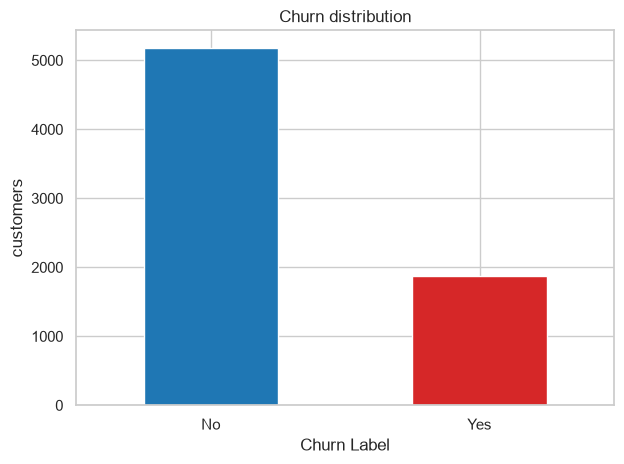

In [5]:
churn_rate = df_raw["Churn Value"].mean()
print(f"churn rate: {churn_rate:.1%}")

ax = df_raw["Churn Label"].value_counts().plot.bar(color=["tab:blue", "tab:red"], rot=0)
ax.set_title("Churn distribution")
ax.set_ylabel("customers")
plt.tight_layout()
plt.show()

## Column-by-column verdict (data leakage detection)

| Columns | Verdict | Why |
|---|---|---|
| `Churn Value` | **target** | what we predict |
| `Churn Label` | drop (leakage) | Yes/No duplicate of the target |
| `Churn Score` | drop (leakage) | output of IBM's *own* churn model — a prediction, not an attribute |
| `Churn Reason` | drop (leakage) | only known **after** the customer churns (null for all non-churners) |
| `CLTV` | drop (leakage risk) | IBM-computed lifetime value; computation isn't documented and may use the outcome |
| `Count`, `Country`, `State` | drop (constant) | one single value for all 7,043 rows — zero information |
| `CustomerID` | drop (identifier) | unique per row; a model could only memorise it |
| `City`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude` | drop (geo) | 1,100+ categories of CA-only geography; high cardinality, high overfit risk, no business lever |
| remaining 19 | **keep** | demographics, contract, services, billing — all known *before* churn |

**The leakage test:** *"Would this value be available at the moment of
prediction, before the customer decides to leave?"* If not, using it makes
offline metrics spectacular and production performance useless.